# Import soccer tracking data into ocel

In [1]:
# imports
import pandas as pd
import numpy as np
import pm4py
from pm4py.objects.ocel.util.log_ocel import log_to_ocel_multiple_obj_types as log_to_ocel
import Soccer_OCEL.helpers as helpers
print(pm4py.__version__)

2.7.15.2


In [2]:
# settings
## Resolution of the grid
x_fields = 20
y_fields = 20

In [3]:
# load data from csvs

tracking_data_away_df = pd.read_csv('sample-data\data\Sample_Game_1\Sample_Game_1_RawTrackingData_Away_Team.csv', skiprows=2)
print('Tracking data away:')
print(tracking_data_away_df.columns)
display(tracking_data_away_df.head())
tracking_data_home_df = pd.read_csv('sample-data\data\Sample_Game_1\Sample_Game_1_RawTrackingData_Home_Team.csv', skiprows=2)
print('Tracking data home:')
print(tracking_data_home_df.columns)
display(tracking_data_home_df.head())

Tracking data away:
Index(['Period', 'Frame', 'Time [s]', 'Player25', 'Unnamed: 4', 'Player15',
       'Unnamed: 6', 'Player16', 'Unnamed: 8', 'Player17', 'Unnamed: 10',
       'Player18', 'Unnamed: 12', 'Player19', 'Unnamed: 14', 'Player20',
       'Unnamed: 16', 'Player21', 'Unnamed: 18', 'Player22', 'Unnamed: 20',
       'Player23', 'Unnamed: 22', 'Player24', 'Unnamed: 24', 'Player26',
       'Unnamed: 26', 'Player27', 'Unnamed: 28', 'Player28', 'Unnamed: 30',
       'Ball', 'Unnamed: 32'],
      dtype='object')


,Period,Frame,Time [s],Player25,Unnamed: 4,Player15,Unnamed: 6,Player16,Unnamed: 8,Player17,...,Player24,Unnamed: 24,Player26,Unnamed: 26,Player27,Unnamed: 28,Player28,Unnamed: 30,Ball,Unnamed: 32
0,1,1,0.04,0.90509,0.47462,0.58393,0.20794,0.67658,0.46710,0.67310,...,0.37833,0.27383,NaN,NaN,NaN,NaN,NaN,NaN,0.45472,0.38709
1,1,2,0.08,0.90494,0.47462,0.58393,0.20794,0.67658,0.46710,0.67310,...,0.37833,0.27383,NaN,NaN,NaN,NaN,NaN,NaN,0.49645,0.40656
2,1,3,0.12,0.90434,0.47463,0.58393,0.20794,0.67658,0.46710,0.67310,...,0.37833,0.27383,NaN,NaN,NaN,NaN,NaN,NaN,0.53716,0.42556
3,1,4,0.16,0.90377,0.47463,0.58351,0.20868,0.67640,0.46762,0.67279,...,0.37756,0.27473,NaN,NaN,NaN,NaN,NaN,NaN,0.55346,0.42231
4,1,5,0.20,0.90324,0.47464,0.58291,0.21039,0.67599,0.46769,0.67253,...,0.37663,0.27543,NaN,NaN,NaN,NaN,NaN,NaN,0.55512,0.40570


Tracking data home:
Index(['Period', 'Frame', 'Time [s]', 'Player11', 'Unnamed: 4', 'Player1',
       'Unnamed: 6', 'Player2', 'Unnamed: 8', 'Player3', 'Unnamed: 10',
       'Player4', 'Unnamed: 12', 'Player5', 'Unnamed: 14', 'Player6',
       'Unnamed: 16', 'Player7', 'Unnamed: 18', 'Player8', 'Unnamed: 20',
       'Player9', 'Unnamed: 22', 'Player10', 'Unnamed: 24', 'Player12',
       'Unnamed: 26', 'Player13', 'Unnamed: 28', 'Player14', 'Unnamed: 30',
       'Ball', 'Unnamed: 32'],
      dtype='object')


,Period,Frame,Time [s],Player11,Unnamed: 4,Player1,Unnamed: 6,Player2,Unnamed: 8,Player3,...,Player10,Unnamed: 24,Player12,Unnamed: 26,Player13,Unnamed: 28,Player14,Unnamed: 30,Ball,Unnamed: 32
0,1,1,0.04,0.00082,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.55243,0.43269,NaN,NaN,NaN,NaN,NaN,NaN,0.45472,0.38709
1,1,2,0.08,0.00096,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.55243,0.43269,NaN,NaN,NaN,NaN,NaN,NaN,0.49645,0.40656
2,1,3,0.12,0.00114,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.55243,0.43269,NaN,NaN,NaN,NaN,NaN,NaN,0.53716,0.42556
3,1,4,0.16,0.00121,0.48238,0.32622,0.65317,0.33687,0.48988,0.30944,...,0.55236,0.43313,NaN,NaN,NaN,NaN,NaN,NaN,0.55346,0.42231
4,1,5,0.20,0.00129,0.48238,0.32597,0.65269,0.33664,0.49018,0.30948,...,0.55202,0.43311,NaN,NaN,NaN,NaN,NaN,NaN,0.55512,0.40570


In [4]:
# reshape the tracking data to long format (one row per player per time point)
def reshape_tracking(df, team_label):
    long_rows = []
    for col in df.columns:
        if col.startswith("Player"):
            x_col = col
            y_col = f"Unnamed: {int(df.columns.get_loc(col)) + 1}"
            for _, row in df.iterrows():
                # only append if X and Y is not NaN
                if pd.notna(row[x_col]) and pd.notna(row[y_col]):
                    long_rows.append({
                        "Time [s]": row["Time [s]"],
                        "Frame": row["Frame"],
                        "Team": team_label.capitalize(),
                        "Player": f"{team_label.capitalize()}_{col}",
                        "X": row[x_col],
                        "Y": row[y_col]
                    })
    return pd.DataFrame(long_rows)

tracking_long_home_df = reshape_tracking(tracking_data_home_df, "home")
tracking_long_away_df = reshape_tracking(tracking_data_away_df, "away")
tracking_long_df = pd.concat([tracking_long_home_df, tracking_long_away_df])
tracking_long_df.head()

,Time [s],Frame,Team,Player,X,Y
0,0.04,1.0,Home,Home_Player11,0.00082,0.48238
1,0.08,2.0,Home,Home_Player11,0.00096,0.48238
2,0.12,3.0,Home,Home_Player11,0.00114,0.48238
3,0.16,4.0,Home,Home_Player11,0.00121,0.48238
4,0.20,5.0,Home,Home_Player11,0.00129,0.48238


In [5]:
def get_field_position(x, y, x_fields = 10, y_fields=10):
    """
    Calculate the position of a field in a grid based on its coordinates.

    Example use on an event dataframe:
    >>> df = pd.DataFrame({'Start X': [0.1, 0.5, 0.9], 'Start Y': [0.2, 0.5, 0.8]})
    >>> df['field_position'] = df.apply(lambda row: get_field_position(row['Start X'], row['Start Y']), axis=1)

    Args:
        x (int): The x-coordinate of the field.
        y (int): The y-coordinate of the field.
        x_fields (int): The number of fields along the x-axis.
        y_fields (int): The number of fields along the y-axis.

    Returns:
        str: A position string in the format "A1", "B2", etc.
    """
    import math

    if x is None or y is None or pd.isna(x) or pd.isna(y):
        return None

    x_pos = math.floor(x * x_fields)
    y_pos = math.floor(y * y_fields)
    if x_pos >= x_fields:
        x_pos = x_fields - 1
    if y_pos >= y_fields:
        y_pos = y_fields - 1

    return (x_pos, y_pos)


In [6]:
# add grid position to tracking long
tracking_long_df['Grid Position'] = tracking_long_df.apply(lambda row: get_field_position(row['X'], row['Y'], x_fields=x_fields, y_fields=y_fields), axis=1)
tracking_long_df.head()

,Time [s],Frame,Team,Player,X,Y,Grid Position
0,0.04,1.0,Home,Home_Player11,0.00082,0.48238,"(0, 9)"
1,0.08,2.0,Home,Home_Player11,0.00096,0.48238,"(0, 9)"
2,0.12,3.0,Home,Home_Player11,0.00114,0.48238,"(0, 9)"
3,0.16,4.0,Home,Home_Player11,0.00121,0.48238,"(0, 9)"
4,0.20,5.0,Home,Home_Player11,0.00129,0.48238,"(0, 9)"


In [7]:
import ast
import networkx as nx
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
def parse_grid_position(pos):
    if isinstance(pos, str):
        return tuple(ast.literal_eval(pos))
    return pos
def generate_cost_map(df, current_player, grid_size=(10, 10), goal=(0, 5), sigma=1):
    #cost_map = np.ones(grid_size)*100

    df['Grid Position'] = df['Grid Position'].apply(parse_grid_position)

    opponent_map = np.zeros(grid_size)
    teammate_map = np.zeros(grid_size)

    for _, row in df.iterrows():
        x, y = row['Grid Position']
        if row['Player'] == current_player:
            continue  # Don't add current player
        if row['Team'] != current_player[:4]:
            opponent_map[x-1:x+1, y-1:y+1] += 40
        else:
            teammate_map[x-1:x+1, y-1:y+1] += 20 

    opponent_influence = gaussian_filter(opponent_map, sigma=sigma)
    teammate_influence = gaussian_filter(teammate_map, sigma=sigma)

    cost_map =  opponent_influence - teammate_influence
    cost_map = np.clip(cost_map, 0, None)  # Ensure no negative costs

    for x in range(grid_size[0]):
        for y in range(grid_size[1]):
            dist = np.linalg.norm(np.array([x, y]) - np.array(goal))
            dist_from_player = np.linalg.norm(np.array([x, y]) - np.array(parse_grid_position(df[df['Player'] == current_player]['Grid Position'].values[0])))
            cost_map[x, y] += dist * 0.1
            cost_map[x, y] += dist_from_player * 0.1
    

    return cost_map

def build_path_graph(cost_map):
    G = nx.grid_2d_graph(*cost_map.shape)

    for (u, v) in G.edges():
        G[u][v]['weight'] = (cost_map[u] + cost_map[v]) / 2

    return G

def find_path(start, goal, graph, x_fields, y_fields):
    try:
        x=start[0]-1
        y=start[1]-1
        if x>=x_fields:
            x=x_fields-1
        elif x<0:
            x=0
        if y>=y_fields:
            y=y_fields-1
        elif y<0:
            y=0
        start = (x, y)

        path = nx.astar_path(graph, start, goal)
        return path
    except nx.NetworkXNoPath:
        return []


def find_best_pass(df, goal=(0, 5), grid_size=(10, 10)):
    df['Grid Position'] = df['Grid Position'].apply(parse_grid_position)
    teammates = df[df['Team'] == 'Home']
    opponents = df[df['Team'] == 'Away']

    best_player = None
    best_path = []
    best_cost = float('inf')

    for _, row in teammates.iterrows():
        current_player = row['Player']
        start = row['Grid Position']
        cost_map = generate_cost_map(df, current_player, grid_size, goal)
        graph = build_path_graph(cost_map)
        path = find_path(start, goal, graph, grid_size[0], grid_size[1])
        if path:
            path_cost = sum(cost_map[x, y] for x, y in path)
            if path_cost < best_cost:
                best_cost = path_cost
                best_path = path
                best_player = current_player

    return best_player, best_path, best_cost

In [17]:
import time
df=tracking_long_df[tracking_long_df['Frame']==2143]#143578]

current_player = "Home_Player6"
start_time = time.time()
start = parse_grid_position(df[df['Player'] == current_player]['Grid Position'].values[0])
end_time = time.time()
print(f"Time to parse start position: {end_time - start_time:.4f} seconds")
goal = (int(1*x_fields-1), int(0.5*y_fields))

start_time = time.time()
cost_map = generate_cost_map(df, current_player, grid_size=(x_fields, y_fields), goal=goal, sigma=1)
end_time = time.time()
print(f"Time to generate cost map: {end_time - start_time:.4f} seconds")
start_time = time.time()
graph = build_path_graph(cost_map)
end_time = time.time()
print(f"Time to build path graph: {end_time - start_time:.4f} seconds")
start_time = time.time()
path = find_path(start, goal, graph, x_fields, y_fields)
end_time = time.time()
print(f"Time to find path: {end_time - start_time:.4f} seconds")

pass_target = "Home_Player10"

Time to parse start position: 0.0020 seconds
Time to generate cost map: 0.0987 seconds
Time to build path graph: 0.0030 seconds
Time to find path: 0.0023 seconds


C:\Users\Vito\AppData\Local\Temp\ipykernel_28176\1021647196.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Grid Position'] = df['Grid Position'].apply(parse_grid_position)


In [9]:
def draw_basemap(ax, x_fields=x_fields, y_fields=y_fields):
    from matplotlib.patches import Ellipse
    for i in range(x_fields + 1):
        ax.plot([i, i], [0, y_fields], color='lightgray', linewidth=1)
    for j in range(y_fields + 1):
        ax.plot([0, x_fields], [j, j], color='lightgray', linewidth=1)
    ax.set_xticks(np.arange(x_fields) + 0.5)
    ax.set_yticks(np.arange(y_fields) + 0.5)
    ax.set_yticklabels([str(i) for i in range(1, y_fields + 1)], fontsize=12)
    ax.set_xticklabels([str(i) for i in range(1, x_fields + 1)], fontsize=12)
    ax.tick_params(axis='both', which='both', length=0)
    pitch_length = 105
    pitch_width = 68

    x_scale = x_fields / pitch_length
    y_scale = y_fields / pitch_width

    ax.plot([x_fields/2, x_fields/2], [0, y_fields],
            color='k', linestyle='--', linewidth=1.5)

    center_circle_radius = 9.15 #* x_scale
    center_circle = Ellipse((x_fields/2, y_fields/2),
                            width=center_circle_radius * 2 * x_scale,
                            height=center_circle_radius * 2 * y_scale,
                            edgecolor='k', facecolor='none', linewidth=1.5)
    ax.add_patch(center_circle)

    goal_area_depth = 5.5 * x_scale
    goal_area_width = 18.32 * y_scale
    goal_y = (y_fields - goal_area_width) / 2

    left_goal_area = plt.Rectangle((0, goal_y),
                                goal_area_depth, goal_area_width,
                                edgecolor='k', facecolor='none', linewidth=1.5)
    ax.add_patch(left_goal_area)

    right_goal_area = plt.Rectangle((x_fields - goal_area_depth, goal_y),
                                    goal_area_depth, goal_area_width,
                                    edgecolor='k', facecolor='none', linewidth=1.5)
    ax.add_patch(right_goal_area)

    ax.set_aspect(68/105)

In [10]:
start

(19, 0)

C:\Users\Vito\AppData\Local\Temp\ipykernel_28176\3886415997.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Grid Position'] = df['Grid Position'].apply(parse_grid_position)


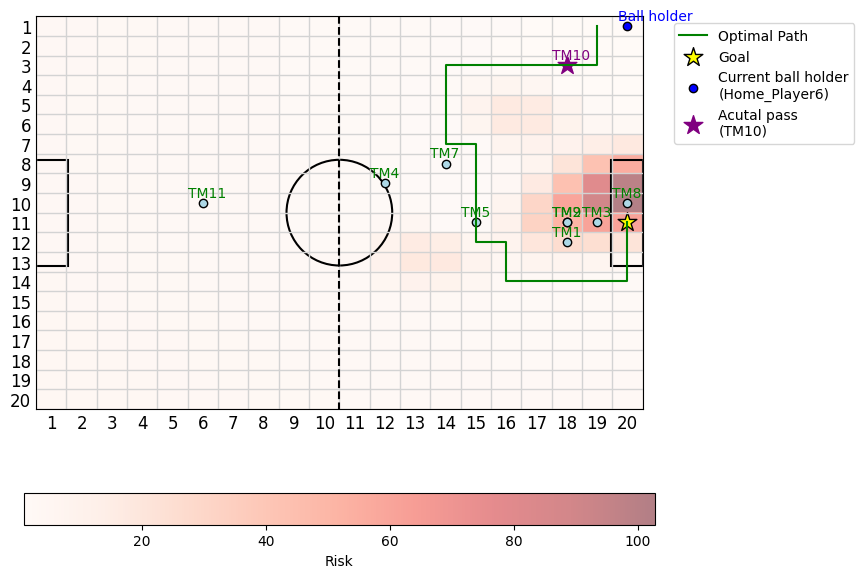

In [42]:
def visualize_path(ball_owner, cost_map, path, start, goal, df, pass_target=None, x_fields=x_fields, y_fields=y_fields):
    import re

    df['Grid Position'] = df['Grid Position'].apply(parse_grid_position)

    plt.figure(figsize=(10, 6))
    fs=10
    im = plt.imshow(cost_map.T, origin='lower', cmap='Reds', interpolation='nearest', alpha=0.5, extent=[0, x_fields, 0, y_fields])
    draw_basemap(plt.gca(), x_fields=x_fields, y_fields=y_fields)

    if path:
        xs, ys = zip(*path)
        plt.plot(np.array(xs)+0.5, np.array(ys)+0.5, color='g', label='Optimal Path')

    plt.scatter(*(np.array(goal) + 0.5), color='yellow', marker='*', s=200, label='Goal', edgecolors='black')
    plt.scatter(*(np.array(start)+0.5), color='blue', label=f'Current ball holder\n({ball_owner})', edgecolors='black')
    plt.text(start[0] + 0.2, start[1] + 0.2, 'Ball holder', fontsize=fs, color='blue')

    for i, (_, row) in enumerate(df.iterrows()):
        player = row['Player']
        team = row['Team']
        pos = row['Grid Position']

        if player == ball_owner:
            continue  

        dx = 0
        dy = 0.2
        player_num = int(re.search(r'\d+', player).group())
        if player == pass_target:
            plt.scatter(*(np.array(pos) + 0.5), color='purple', marker='*', s=200, label=f'Acutal pass\n(TM{player_num})')
            plt.text(pos[0] + dx, pos[1] + dy, f'TM{player_num}', fontsize=fs, color='purple')
        elif team == ball_owner[:4]:  # teammate
            plt.scatter(*(np.array(pos) + 0.5), color='lightblue', edgecolors='black')
            plt.text(pos[0] + dx, pos[1] + dy, f'TM{player_num}', fontsize=fs, color='green')
        #else:  # opponent
            #plt.scatter(*(np.array(pos) + 0.5), color='red', edgecolors='black')
            #plt.text(pos[0] +dx, pos[1]+dy , f'OP{player_num}', fontsize=fs, color='red')

    plt.colorbar(im, label='Risk', shrink=0.7, orientation='horizontal')

    plt.gca().invert_yaxis()
    plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", fontsize=fs)
    #plt.grid(True)
    plt.tight_layout()
    plt.show()

visualize_path(current_player,cost_map, path, start, goal, df, pass_target=pass_target)


risk of interception= distance to the football player+distance to the closest oppannat/distance to the closest teammate+

pass evaluation: to each teammate, consider opponants who are closer to the ball than the teammate, draw a straight line between ball holder and the temmate and take a shortest intersection course. for each qualifying opponant, take the division of the distance between ball and interception and opponant and interception. pass score will then be the aggregation of all qualified opponant

In [43]:
def calculate_teammate_pass_risk(df, ball_holder):
    df = df.copy()
    df['Grid Position'] = df['Grid Position'].apply(parse_grid_position)

    ball_team = df.loc[df['Player'] == ball_holder, 'Team'].iloc[0]
    ball_pos = np.array(df.loc[df['Player'] == ball_holder, 'Grid Position'].iloc[0])

    teammates = df[(df['Team'] == ball_team) & (df['Player'] != ball_holder)]
    opponents = df[df['Team'] != ball_team]

    def distance(a, b):
        return np.linalg.norm(a - b)

    scores = {}
    

    for _, t_row in teammates.iterrows():
        teammate_pos = np.array(t_row['Grid Position'])
        potential_interceptors=0
        dist_ball_teammate = distance(ball_pos, teammate_pos)

        valid_opponents = opponents[
            opponents['Grid Position'].apply(lambda p: distance(ball_pos, np.array(p)) < dist_ball_teammate)
        ]

        max_risk = 0
        bt_vec = teammate_pos - ball_pos
        bt_len = np.linalg.norm(bt_vec)

        if bt_len == 0:
            scores[t_row['Player']] = 0
            continue

        for _, o_row in valid_opponents.iterrows():
            opp_pos = np.array(o_row['Grid Position'])
            bo_vec = opp_pos - ball_pos
            if np.dot(bo_vec, bt_vec) <= 0:
                continue
            
            t = np.dot(opp_pos - ball_pos, bt_vec) / (bt_len ** 2)
            t = max(0, min(1, t))

            intersection = ball_pos + t * bt_vec
            dist_ball_intersection = distance(ball_pos, intersection)
            dist_opp_intersection = distance(opp_pos, intersection)

            if dist_opp_intersection > 0:
                if dist_ball_intersection/dist_opp_intersection >= 0.9:
                    potential_interceptors += 1
                max_risk= np.max([max_risk, dist_ball_intersection / dist_opp_intersection])
            

        scores[t_row['Player']] = max_risk*potential_interceptors*dist_ball_teammate

    return scores

teammate_scores = calculate_teammate_pass_risk(df, current_player)
print("Teammate scores based on blocking ratios:")
for player, score in teammate_scores.items():
    print(f"{player}: {score:.2f}")
print(f'Best pass target: {min(teammate_scores, key=teammate_scores.get)} with score {min(teammate_scores.values()):.2f}')

Teammate scores based on blocking ratios:
Home_Player11: 168.37
Home_Player1: 5735.51
Home_Player2: 728.14
Home_Player3: 602.99
Home_Player4: 452.55
Home_Player5: 1308.10
Home_Player7: 271.46
Home_Player8: 15.00
Home_Player9: 728.14
Home_Player10: 0.00
Best pass target: Home_Player10 with score 0.00


In [ ]:
take the most risky successful pass as threshold

have one log with just pass
another with recipient/role encoded

In [41]:
def calculate_teammate_goal_chance(df, ball_holder, goal):
    df = df.copy()
    df['Grid Position'] = df['Grid Position'].apply(parse_grid_position)

    ball_team = df.loc[df['Player'] == ball_holder, 'Team'].iloc[0]
    #ball_pos = np.array(df.loc[df['Player'] == ball_holder, 'Grid Position'].iloc[0])

    shooters = df[(df['Team'] == ball_team)]
    opponents = df[df['Team'] != ball_team]
    goal_center = np.array(goal)
    
    def distance(a, b):
        return np.linalg.norm(a - b)

    scores = {}
    potential_interceptors=0
    for _, s_row in shooters.iterrows():
        shooter_pos = np.array(s_row['Grid Position'])
        sg_vec = goal_center - shooter_pos
        sg_len = np.linalg.norm(sg_vec)

        if sg_len == 0:
            scores[s_row['Player']] = 0
            continue

        max_risk = 0
        potential_interceptors = 0

        for _, o_row in opponents.iterrows():
            opp_pos = np.array(o_row['Grid Position'])
            so_vec = opp_pos - shooter_pos

            if np.dot(sg_vec, so_vec) <= 0:
                continue

            # Project opponent onto shot line
            t = np.dot(opp_pos - shooter_pos, sg_vec) / (sg_len ** 2)
            t = max(0, min(1, t)) 

            intersection = shooter_pos + t * sg_vec
            dist_shooter_intersection = distance(shooter_pos, intersection)
            dist_opp_intersection = distance(opp_pos, intersection)

            if dist_opp_intersection > 0:
                if dist_shooter_intersection / dist_opp_intersection >= 0.9:
                    potential_interceptors += 1
                max_risk = max(max_risk, dist_shooter_intersection / dist_opp_intersection)

        scores[s_row['Player']] = max_risk * potential_interceptors

    return scores

teammate_goal = calculate_teammate_goal_chance(df, current_player, goal)
print("Teammate goal chance based on blocking ratios:")
for player, score in teammate_goal.items():
    print(f"{player}: {score:.2f}")
print(f'Best shooter: {min(teammate_goal, key=teammate_goal.get)} with score {min(teammate_goal.values()):.2f}')

Teammate goal chance based on blocking ratios:
Home_Player11: 1830.00
Home_Player1: 15.00
Home_Player2: 8.00
Home_Player3: 3.00
Home_Player4: 270.00
Home_Player5: 25.00
Home_Player6: 60.00
Home_Player7: 104.00
Home_Player8: 1.00
Home_Player9: 8.00
Home_Player10: 300.00
Best shooter: Home_Player8 with score 1.00


In [44]:
def build_pass_graph(df, goalkeeper):
    """
    Build a weighted directed graph of teammates where edge weights = pass risk.
    Excludes the goalkeeper from being a pass target.
    """
    G = nx.DiGraph()

    players = df['Player'].unique()
    for player in players:
        if player == goalkeeper:
            continue  # skip GK as passer

        risks = calculate_teammate_pass_risk(df, player)

        for teammate, risk in risks.items():
            if teammate == goalkeeper:
                continue  # skip GK as receiver
            G.add_edge(player, teammate, weight=risk)

    return G


def best_pass_path(df, ball_holder, shooter, goalkeeper, strategy="sum"):
    """
    Find the pass sequence from ball_holder to shooter under different strategies.

    Parameters
    ----------
    df : DataFrame
        Must have columns ['Player', 'Team', 'Grid Position'].
    ball_holder : str
        The player currently holding the ball.
    shooter : str
        The teammate we want to deliver the ball to.
    goalkeeper : str
        The goalkeeper to exclude from consideration.
    strategy : str, optional
        "sum"    -> minimize total accumulated risk (default)
        "avg"    -> minimize average risk per pass
        "local" -> always pass to least risky teammate until shooter is reached
    """
    if shooter == goalkeeper:
        return None, float('inf')  # cannot pass to GK

    G = build_pass_graph(df, goalkeeper)

    if strategy == "sum":
        try:
            path = nx.dijkstra_path(G, source=ball_holder, target=shooter, weight='weight')
            risk = nx.dijkstra_path_length(G, source=ball_holder, target=shooter, weight='weight')
            return path, risk
        except nx.NetworkXNoPath:
            return None, float('inf')

    elif strategy == "avg":
        paths = nx.all_simple_paths(G, source=ball_holder, target=shooter)
        best_path, best_score = None, float('inf')
        for path in paths:
            risks = [G[path[i]][path[i+1]]['weight'] for i in range(len(path)-1)]
            avg_risk = np.mean(risks)
            if avg_risk < best_score:
                best_score = avg_risk
                best_path = path
        return best_path, best_score

    elif strategy == "local":
        current = ball_holder
        path = [current]
        total_risk = 0
        visited = set([current])
        while current != shooter:
            neighbors = [(nbr, G[current][nbr]['weight']) for nbr in G.successors(current) if nbr not in visited]
            if not neighbors:
                return None, float('inf')
            next_player, risk = min(neighbors, key=lambda x: x[1])  # least risky
            path.append(next_player)
            total_risk += risk
            visited.add(next_player)
            current = next_player
        return path, total_risk

    else:
        raise ValueError("strategy must be one of: 'sum', 'avg', 'local'")

goalkeeper='Home_Player11'
path_sum, risk_sum = best_pass_path(df, current_player, min(teammate_goal, key=teammate_goal.get), goalkeeper, strategy="sum")
path_avg, risk_avg = best_pass_path(df, current_player, min(teammate_goal, key=teammate_goal.get), goalkeeper, strategy="avg")
path_local, risk_local = best_pass_path(df, current_player, min(teammate_goal, key=teammate_goal.get), goalkeeper,strategy="local")
print('Passing from', current_player, 'to', min(teammate_goal, key=teammate_goal.get))

print("Min total risk:", path_sum, risk_sum)
print("Min avg risk:", path_avg, risk_avg)
print("local path:", path_local, risk_local)

Passing from Home_Player6 to Home_Player8
Min total risk: ['Home_Player6', 'Home_Player8'] 15.0
Min avg risk: ['Home_Player6', 'Home_Player10', 'Home_Player7', 'Home_Player4', 'Home_Player5', 'Home_Player2', 'Home_Player1', 'Home_Player9', 'Home_Player3', 'Home_Player8'] 2.088235800759299
local path: ['Home_Player6', 'Home_Player10', 'Home_Player7', 'Home_Player2', 'Home_Player1', 'Home_Player5', 'Home_Player4', 'Home_Player9', 'Home_Player3', 'Home_Player8'] 25.11867752717045


C:\Users\Vito\AppData\Local\Temp\ipykernel_21312\1021647196.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Grid Position'] = df['Grid Position'].apply(parse_grid_position)
C:\Users\Vito\AppData\Local\Temp\ipykernel_21312\1021647196.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Grid Position'] = df['Grid Position'].apply(parse_grid_position)


Best player to shoot: Home_Player5


C:\Users\Vito\AppData\Local\Temp\ipykernel_21312\467879020.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Grid Position'] = df['Grid Position'].apply(parse_grid_position)


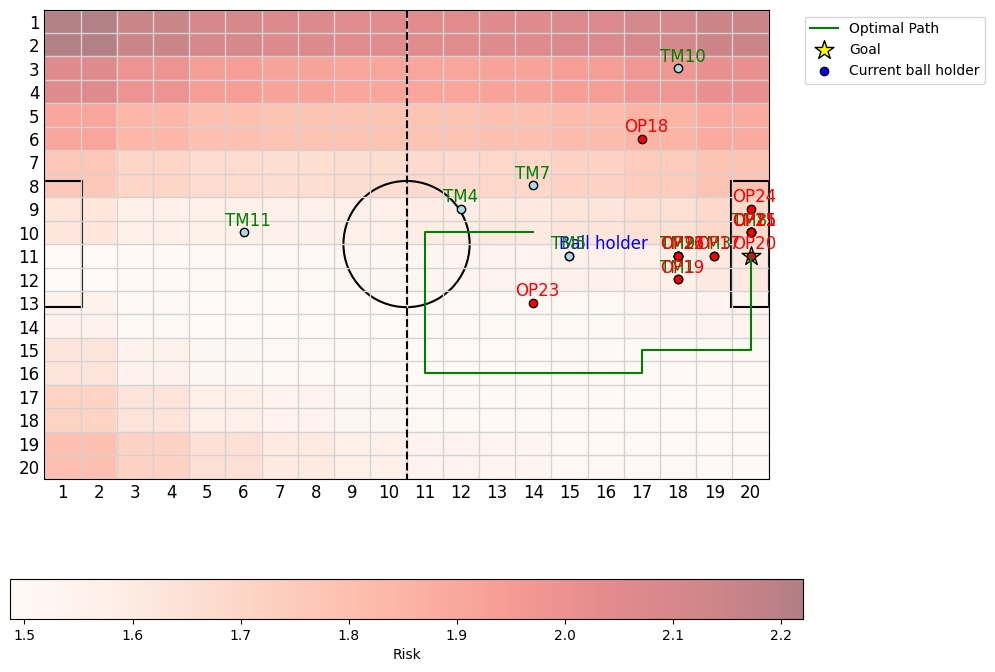

In [51]:
best_option, best_path, best_cost = find_best_pass(df, grid_size=(x_fields, y_fields), goal=goal)
print(f"Best player to shoot: {best_option}")
visualize_path(current_player,generate_cost_map(df, best_option), best_path, parse_grid_position(df[df['Player'] == best_option]['Grid Position'].values[0]), goal, df)


In [ ]:
#13 pass to 4, home team. player 4 lost the ball at 143598

In [ ]:
def calculate_pass_cost(start, target, cost_map):
    graph = build_path_graph(cost_map)
    path = find_path(start, target, graph)
    
    if not path:
        return [], float('inf')  # No path found
    
    total_cost = sum(cost_map[x, y] for x, y in path)
    return path, total_cost
start = parse_grid_position(df[df['Player'] == current_player]['Grid Position'].values[0])
target = parse_grid_position(df[df['Player'] == pass_target]['Grid Position'].values[0])

path_to_player4, pass_cost = calculate_pass_cost(start, target, cost_map)

print(f"Pass cost from {current_player} to {pass_target}: {pass_cost:.2f}")

def evaluate_all_pass_options(df, ball_owner, cost_map):
    results = []
    start = parse_grid_position(df[df['Player'] == ball_owner]['Grid Position'].values[0])
    
    for _, row in df.iterrows():
        if row['Player'] == ball_owner or row['Team'] != ball_owner[:4]:
            continue  # Skip self and opponents
        target = row['Grid Position']
        path, cost = calculate_pass_cost(start, target, cost_map)
        results.append((row['Player'], cost, path))
    
    # Sort by cost (lower is better)
    results.sort(key=lambda x: x[1])
    return results
results = evaluate_all_pass_options(df, current_player, cost_map)

target = parse_grid_position(df[df['Player'] == results[np.argmin([i[1] for i in results])][0]]['Grid Position'].values[0])

path_to_player4, pass_cost = calculate_pass_cost(start, target, cost_map)

print(f"Pass cost from {current_player} to {results[np.argmin([i[1] for i in results])][0]}: {pass_cost:.2f}")

Pass cost from Home_Player13 to Home_Player4: 115.03
Pass cost from Home_Player13 to Home_Player4: 115.03


'Home_Player4'

In [16]:
import numpy as np
np.ones((x_fields, y_fields))

array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])

In [13]:
# identify only events when grid position of player changes
def get_grid_change_events(tracking_df):
    tracking_df = tracking_df.sort_values(by=['Player', 'Time [s]'])
    tracking_df['Prev Grid Position'] = tracking_df.groupby('Player')['Grid Position'].shift(1)
    grid_change_events = tracking_df[tracking_df['Grid Position'] != tracking_df['Prev Grid Position']]
    grid_change_events.rename(columns={'Grid Position': 'To Position', 
                                'Prev Grid Position': 'From Position'}, inplace=True
                       )
    return grid_change_events

tracking_grid_change_events_df = get_grid_change_events(tracking_long_df)
display(tracking_grid_change_events_df.head())

C:\Users\Lennart\AppData\Local\Temp\ipykernel_40244\249922193.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grid_change_events.rename(columns={'Grid Position': 'To Position',


,Time [s],Frame,Team,Player,X,Y,To Position,From Position
145006,0.04,1.0,Away,Away_Player15,0.58393,0.20794,F3,NaN
145029,0.96,24.0,Away,Away_Player15,0.56821,0.19967,F2,F3
145084,3.16,79.0,Away,Away_Player15,0.54274,0.20009,F3,F2
145160,6.20,155.0,Away,Away_Player15,0.54714,0.30046,F4,F3
145223,8.72,218.0,Away,Away_Player15,0.50298,0.40046,F5,F4


In [14]:
# format dataframe for ocel
def format_ocel_df(tracking_df):
    ocel_df = tracking_df.copy()
    ocel_df['concept:name'] = "Player moved to " + ocel_df['To Position'].astype(str)
    ocel_df['case:concept:name'] = ocel_df['Team']
    ocel_df['time:timestamp'] = pd.to_datetime(ocel_df['Time [s]'], unit='s')
    
    return ocel_df

ocel_df = format_ocel_df(tracking_grid_change_events_df)
ocel_df

,Time [s],Frame,Team,Player,X,Y,To Position,From Position,concept:name,case:concept:name,time:timestamp
145006,0.04,1.0,Away,Away_Player15,0.58393,0.20794,F3,NaN,Player moved to F3,Away,1970-01-01 00:00:00.040
145029,0.96,24.0,Away,Away_Player15,0.56821,0.19967,F2,F3,Player moved to F2,Away,1970-01-01 00:00:00.960
145084,3.16,79.0,Away,Away_Player15,0.54274,0.20009,F3,F2,Player moved to F3,Away,1970-01-01 00:00:03.160
145160,6.20,155.0,Away,Away_Player15,0.54714,0.30046,F4,F3,Player moved to F4,Away,1970-01-01 00:00:06.200
145223,8.72,218.0,Away,Away_Player15,0.50298,0.40046,F5,F4,Player moved to F5,Away,1970-01-01 00:00:08.720
...,...,...,...,...,...,...,...,...,...,...,...
1317161,5782.60,144565.0,Home,Home_Player9,0.11281,0.79993,B8,B9,Player moved to B8,Home,1970-01-01 01:36:22.600
1317173,5783.08,144577.0,Home,Home_Player9,0.11286,0.80001,B9,B8,Player moved to B9,Home,1970-01-01 01:36:23.080
1317273,5787.08,144677.0,Home,Home_Player9,0.11225,0.79987,B8,B9,Player moved to B8,Home,1970-01-01 01:36:27.080
1317345,5789.96,144749.0,Home,Home_Player9,0.11105,0.80019,B9,B8,Player moved to B9,Home,1970-01-01 01:36:29.960


In [15]:
# count isna in "to position" format_ocel_df
print("Count of NaN in 'To Position':", ocel_df['To Position'].isna().sum())

Count of NaN in 'To Position': 0


In [16]:
# convert data frame to event log
event_log = pm4py.convert_to_event_log(ocel_df)

In [17]:
# convert event log to ocel
ocel = log_to_ocel(event_log, activity_column='concept:name', 
                   timestamp_column='time:timestamp', 
                   obj_types=['Team','Player', 'To Position', 'From Position'])

In [18]:
# show how the ocel looks now
ocel.get_extended_table()

,ocel:eid,ocel:activity,ocel:timestamp,ocel:type:Team,ocel:type:Player,ocel:type:To Position,ocel:type:From Position
0,0,Player moved to F3,1970-01-01 00:00:00.040,[Away],[Away_Player15],[F3],NaN
1,1,Player moved to F2,1970-01-01 00:00:00.960,[Away],[Away_Player15],[F2],[F3]
2,2,Player moved to F3,1970-01-01 00:00:03.160,[Away],[Away_Player15],[F3],[F2]
3,3,Player moved to F4,1970-01-01 00:00:06.200,[Away],[Away_Player15],[F4],[F3]
4,4,Player moved to F5,1970-01-01 00:00:08.720,[Away],[Away_Player15],[F5],[F4]
...,...,...,...,...,...,...,...
32343,32343,Player moved to B8,1970-01-01 01:36:22.600,[Home],[Home_Player9],[B8],[B9]
32344,32344,Player moved to B9,1970-01-01 01:36:23.080,[Home],[Home_Player9],[B9],[B8]
32345,32345,Player moved to B8,1970-01-01 01:36:27.080,[Home],[Home_Player9],[B8],[B9]
32346,32346,Player moved to B9,1970-01-01 01:36:29.960,[Home],[Home_Player9],[B9],[B8]


In [19]:
# write ocel out to .jsonocel
path = "tracking_game1.jsonocel"
pm4py.write_ocel(ocel, path)